In [ ]:
import torch
import torch.nn as nn
import timm

import torchvision
from torchvision import datasets, transforms

from torch.utils.data import DataLoader

from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:",device)

Device: cuda


# **BASELINE**

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor()

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor()

])

In [ ]:
train_dataset = datasets.MNIST(

    root="./data",

    train=True,

    download=True,

    transform=train_transform

)


test_dataset = datasets.MNIST(

    root="./data",

    train=False,

    download=True,

    transform=test_transform

)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.07MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.05MB/s]


In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)


scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device

):

    model.train()

    running_loss=0


    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)


        optimizer.zero_grad()


        outputs=model(images)


        loss=criterion(

            outputs,

            labels

        )


        loss.backward()


        optimizer.step()


        running_loss+=loss.item()


    return running_loss/len(loader)

In [ ]:
def evaluate(

    model,

    criterion,

    loader,

    device

):

    model.eval()


    loss_total=0

    correct=0

    total=0


    with torch.no_grad():


        for images,labels in tqdm(loader):


            images=images.to(device)

            labels=labels.to(device)


            outputs=model(images)


            loss=criterion(

                outputs,

                labels

            )


            loss_total+=loss.item()


            pred=torch.argmax(

                outputs,

                dim=1

            )


            correct+=(pred==labels).sum().item()


            total+=labels.size(0)



    return (

        loss_total/len(loader),

        100*correct/total

    )

In [ ]:
criterion=nn.CrossEntropyLoss()


checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_baseline_checkpoint.pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_baseline_best.pth"


epochs=20


best_acc=0


for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device

    )


    val_loss,val_acc=evaluate(

        model,

        criterion,

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss:{train_loss:.4f}"
    )


    print(
        f"Val Loss:{val_loss:.4f}"
    )


    print(
        f"Val Accuracy:{val_acc:.2f}%"
    )



    if val_acc>best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  9.06it/s]


----------------
Epoch 1/20
Train Loss:0.0730
Val Loss:0.0413
Val Accuracy:98.74%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.16it/s]


----------------
Epoch 2/20
Train Loss:0.0256
Val Loss:0.0345
Val Accuracy:98.92%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:16<00:00,  9.28it/s]


...

----------------
Epoch 18/20
Train Loss:0.0000
Val Loss:0.0137
Val Accuracy:99.66%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.11it/s]


----------------
Epoch 19/20
Train Loss:0.0000
Val Loss:0.0138
Val Accuracy:99.66%
Checkpoint saved


100%|██████████| 157/157 [00:16<00:00,  9.25it/s]


----------------
Epoch 20/20
Train Loss:0.0000
Val Loss:0.0138
Val Accuracy:99.66%
Checkpoint saved


# **MIXUP**

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Fresh ViT-Tiny Mixup model loaded")

Fresh ViT-Tiny Mixup model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)


scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=0.0,

    prob=1.0,

    switch_prob=0.0,

    num_classes=10

)

criterion = SoftTargetCrossEntropy()

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_checkpoint.pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_best.pth"

In [ ]:
epochs=20

best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:18<00:00,  8.70it/s]


----------------
Epoch 1/20
Train Loss: 1.0833
Val Loss: 0.1557
Val Accuracy: 99.43%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.47it/s]


----------------
Epoch 2/20
Train Loss: 0.9669
Val Loss: 0.1395
Val Accuracy: 99.37%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.05it/s]


...

----------------
Epoch 18/20
Train Loss: 0.8819
Val Loss: 0.1099
Val Accuracy: 99.64%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.97it/s]


----------------
Epoch 19/20
Train Loss: 0.8822
Val Loss: 0.1078
Val Accuracy: 99.67%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.04it/s]


----------------
Epoch 20/20
Train Loss: 0.8841
Val Loss: 0.1082
Val Accuracy: 99.67%
Checkpoint saved


# **CUTMIX**

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Fresh ViT-Tiny CutMix model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Fresh ViT-Tiny CutMix model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=0.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=1.0,

    num_classes=10

)

In [ ]:
criterion = SoftTargetCrossEntropy()

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )


        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_cutmix_checkpoint.pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_cutmix_best.pth"

In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  9.19it/s]


----------------
Epoch 1/20
Train Loss: 1.2981
Val Loss: 0.2215
Val Accuracy: 99.27%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.36it/s]


----------------
Epoch 2/20
Train Loss: 1.1310
Val Loss: 0.2053
Val Accuracy: 99.31%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.09it/s]


...

100%|██████████| 157/157 [00:18<00:00,  8.59it/s]


----------------
Epoch 11/20
Train Loss: 1.0190
Val Loss: 0.1556
Val Accuracy: 99.55%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.15it/s]


----------------
Epoch 12/20
Train Loss: 1.0067
Val Loss: 0.1634
Val Accuracy: 99.59%
Best model saved
Checkpoint saved


  1%|▏         | 12/938 [00:03<03:40,  4.19it/s]

In [ ]:
epochs = 20

for epoch in range(start_epoch, epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:19<00:00,  8.17it/s]


----------------
Epoch 13/20
Train Loss: 1.0070
Val Loss: 0.1655
Val Accuracy: 99.68%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.93it/s]


----------------
Epoch 14/20
Train Loss: 1.0042
Val Loss: 0.1558
Val Accuracy: 99.55%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.10it/s]


...

----------------
Epoch 18/20
Train Loss: 0.9941
Val Loss: 0.1648
Val Accuracy: 99.66%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.11it/s]


----------------
Epoch 19/20
Train Loss: 1.0006
Val Loss: 0.1658
Val Accuracy: 99.68%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.20it/s]


----------------
Epoch 20/20
Train Loss: 0.9836
Val Loss: 0.1617
Val Accuracy: 99.68%
Checkpoint saved


In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_cutmix_checkpoint.pth"


checkpoint=torch.load(

    checkpoint_path,

    map_location=device

)


model.load_state_dict(

    checkpoint["model_state_dict"]

)


optimizer.load_state_dict(

    checkpoint["optimizer_state_dict"]

)


scheduler.load_state_dict(

    checkpoint["scheduler_state_dict"]

)


start_epoch = checkpoint["epoch"] + 1


best_acc = checkpoint["best_acc"]



print("Resuming from epoch:", start_epoch)

print("Best accuracy:", best_acc)

Resuming from epoch: 12
Best accuracy: 99.59


# **RANDAUGMENT**

In [ ]:
from torchvision import transforms


train_transform = transforms.Compose([

    transforms.Resize((224,224)),


    transforms.Grayscale(
        num_output_channels=3
    ),


    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),


    transforms.ToTensor()

])



test_transform = transforms.Compose([

    transforms.Resize((224,224)),


    transforms.Grayscale(
        num_output_channels=3
    ),


    transforms.ToTensor()

])

In [ ]:
from torchvision.datasets import MNIST


train_dataset = MNIST(

    root="./data",

    train=True,

    download=True,

    transform=train_transform

)


test_dataset = MNIST(

    root="./data",

    train=False,

    download=True,

    transform=test_transform

)

In [ ]:
from torch.utils.data import DataLoader


train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Fresh ViT-Tiny RandAugment model loaded")

Fresh ViT-Tiny RandAugment model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)


criterion = nn.CrossEntropyLoss()

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )


        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_randaugment_best.pth"

In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  9.15it/s]


----------------
Epoch 1/20
Train Loss: 0.1392
Val Loss: 0.0244
Val Accuracy: 99.26%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.19it/s]


----------------
Epoch 2/20
Train Loss: 0.0408
Val Loss: 0.0301
Val Accuracy: 99.06%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.79it/s]


...

100%|██████████| 157/157 [00:17<00:00,  8.94it/s]


----------------
Epoch 5/20
Train Loss: 0.0226
Val Loss: 0.0213
Val Accuracy: 99.38%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.00it/s]


----------------
Epoch 6/20
Train Loss: 0.0192
Val Loss: 0.0291
Val Accuracy: 99.17%
Checkpoint saved


 29%|██▉       | 272/938 [01:11<02:46,  4.00it/s]

In [ ]:
epochs = 20

for epoch in range(start_epoch, epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        nn.CrossEntropyLoss(),
        test_loader,
        device
    )

    scheduler.step()

    print("----------------")
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved")

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_acc": best_acc
        },
        checkpoint_path
    )

    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  8.86it/s]


----------------
Epoch 8/20
Train Loss: 0.3768
Val Loss: 0.1617
Val Accuracy: 99.68%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.73it/s]


----------------
Epoch 9/20
Train Loss: 0.2247
Val Loss: 0.0779
Val Accuracy: 99.64%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.86it/s]


...

----------------
Epoch 18/20
Train Loss: 0.0164
Val Loss: 0.0152
Val Accuracy: 99.49%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.14it/s]


----------------
Epoch 19/20
Train Loss: 0.0171
Val Loss: 0.0107
Val Accuracy: 99.63%
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  9.05it/s]


----------------
Epoch 20/20
Train Loss: 0.0151
Val Loss: 0.0341
Val Accuracy: 99.05%
Checkpoint saved


In [ ]:
epochs = 21

for epoch in range(start_epoch, epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        nn.CrossEntropyLoss(),
        test_loader,
        device
    )

    scheduler.step()

    print("----------------")
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved")

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_acc": best_acc
        },
        checkpoint_path
    )

    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  9.01it/s]


----------------
Epoch 21/21
Train Loss: 0.0172
Val Loss: 0.0140
Val Accuracy: 99.62%
Checkpoint saved


In [ ]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

scheduler.load_state_dict(
    checkpoint["scheduler_state_dict"]
)

best_acc = checkpoint["best_acc"]

start_epoch = checkpoint["epoch"] + 1

print("Resume from:", start_epoch)

Resume from: 20


In [ ]:
start_epoch = checkpoint["epoch"] - 1

best_acc = checkpoint["best_acc"]

print("Resume from epoch:", start_epoch)

print("Best Accuracy:", best_acc)

Resume from epoch: 7
Best Accuracy: 99.53


In [ ]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print(checkpoint["epoch"])
print(checkpoint["best_acc"])

8
99.53


# **MIXUP+CUTMIX**

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Fresh ViT-Tiny Mixup+CutMix model loaded")

Fresh ViT-Tiny Mixup+CutMix model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

In [ ]:
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    num_classes=10

)


criterion = SoftTargetCrossEntropy()

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_checkpoint.pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_best.pth"

In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:17<00:00,  8.94it/s]


----------------
Epoch 1/20
Train Loss: 1.0764
Val Loss: 0.2075
Val Accuracy: 99.26%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.44it/s]


----------------
Epoch 2/20
Train Loss: 1.0519
Val Loss: 0.1746
Val Accuracy: 99.38%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:17<00:00,  8.78it/s]


...

----------------
Epoch 18/20
Train Loss: 0.9458
Val Loss: 0.1525
Val Accuracy: 99.65%
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.69it/s]


----------------
Epoch 19/20
Train Loss: 0.9513
Val Loss: 0.1547
Val Accuracy: 99.64%
Checkpoint saved


100%|██████████| 157/157 [00:18<00:00,  8.43it/s]


----------------
Epoch 20/20
Train Loss: 0.9608
Val Loss: 0.1547
Val Accuracy: 99.64%
Checkpoint saved


# **MIXUP + RANDAUGMENT**

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [ ]:
from torchvision.datasets import MNIST


train_dataset = MNIST(

    root="./data",

    train=True,

    download=True,

    transform=train_transform

)


test_dataset = MNIST(

    root="./data",

    train=False,

    download=True,

    transform=test_transform

)

In [ ]:
from torch.utils.data import DataLoader


train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Fresh ViT-Tiny Mixup+RandAugment model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Fresh ViT-Tiny Mixup+RandAugment model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=0.0,

    prob=1.0,

    switch_prob=0.0,

    num_classes=10

)

In [ ]:
criterion = SoftTargetCrossEntropy()

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_randaugment_checkpoint (1).pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_randaugment_best.pth"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:19<00:00,  8.07it/s]


----------------
Epoch 1/20
Train Loss: 0.9100
Val Loss: 0.1149
Val Accuracy: 99.62%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  7.90it/s]


----------------
Epoch 2/20
Train Loss: 0.9092
Val Loss: 0.1099
Val Accuracy: 99.61%
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.12it/s]


...

100%|██████████| 157/157 [00:19<00:00,  8.11it/s]


----------------
Epoch 12/20
Train Loss: 0.8928
Val Loss: 0.1060
Val Accuracy: 99.70%
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.14it/s]


----------------
Epoch 13/20
Train Loss: 0.8865
Val Loss: 0.1060
Val Accuracy: 99.68%
Checkpoint saved


  5%|▌         | 48/938 [00:14<04:37,  3.20it/s]

In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:19<00:00,  8.11it/s]


----------------
Epoch 1/20
Train Loss: 0.8856
Val Loss: 0.1058
Val Accuracy: 99.71%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.60it/s]


----------------
Epoch 2/20
Train Loss: 0.8786
Val Loss: 0.1056
Val Accuracy: 99.71%
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.23it/s]


...

100%|██████████| 157/157 [00:21<00:00,  7.46it/s]


----------------
Epoch 6/20
Train Loss: 0.8928
Val Loss: 0.1077
Val Accuracy: 99.71%
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.59it/s]


----------------
Epoch 7/20
Train Loss: 0.8895
Val Loss: 0.1055
Val Accuracy: 99.73%
Best model saved
Checkpoint saved


 14%|█▍        | 134/938 [00:39<04:05,  3.28it/s]

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device)
print(checkpoint["epoch"])

6


In [ ]:
# Load checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

# Restore everything
model.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

scheduler.load_state_dict(
    checkpoint["scheduler_state_dict"]
)

best_acc = checkpoint["best_acc"]

# Resume from next epoch
start_epoch = checkpoint["epoch"] + 1

print(f"Resuming from Epoch {start_epoch + 1}/20")
print(f"Best Accuracy: {best_acc:.2f}%")

epochs = 20

# Continue training
for epoch in range(start_epoch, epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        augmentation
    )

    val_loss, val_acc = evaluate(
        model,
        nn.CrossEntropyLoss(),
        test_loader,
        device
    )

    scheduler.step()

    print("----------------")
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved")

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_acc": best_acc
        },
        checkpoint_path
    )

    print("Checkpoint saved")

Resuming from Epoch 8/20
Best Accuracy: 99.73%


100%|██████████| 157/157 [00:22<00:00,  7.06it/s]


----------------
Epoch 8/20
Train Loss: 0.8851
Val Loss: 0.1079
Val Accuracy: 99.59%
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  7.99it/s]


----------------
Epoch 9/20
Train Loss: 0.8915
Val Loss: 0.1090
Val Accuracy: 99.69%
Checkpoint saved


...

----------------
Epoch 18/20
Train Loss: 0.9079
Val Loss: 0.1124
Val Accuracy: 99.61%
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.16it/s]


----------------
Epoch 19/20
Train Loss: 0.9197
Val Loss: 0.1111
Val Accuracy: 99.61%
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.81it/s]


----------------
Epoch 20/20
Train Loss: 0.9094
Val Loss: 0.1059
Val Accuracy: 99.63%
Checkpoint saved


# **CUTMIX + RANDAUGMENT**

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [ ]:
from torchvision.datasets import MNIST


train_dataset = MNIST(

    root="./data",

    train=True,

    download=True,

    transform=train_transform

)


test_dataset = MNIST(

    root="./data",

    train=False,

    download=True,

    transform=test_transform

)

In [ ]:
from torch.utils.data import DataLoader


train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print("Fresh ViT-Tiny CutMix + RandAugment model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Fresh ViT-Tiny CutMix + RandAugment model loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=0.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=1.0,

    num_classes=10

)

criterion = SoftTargetCrossEntropy()

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_cutmix_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_cutmix_randaugment_best.pth"

In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:19<00:00,  8.15it/s]


----------------
Epoch 1/20
Train Loss: 1.2159
Val Loss: 0.2026
Val Accuracy: 99.33%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  7.96it/s]


----------------
Epoch 2/20
Train Loss: 1.1705
Val Loss: 0.2117
Val Accuracy: 99.45%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.01it/s]


...

100%|██████████| 157/157 [00:19<00:00,  8.06it/s]


----------------
Epoch 16/20
Train Loss: 1.0381
Val Loss: 0.1642
Val Accuracy: 99.64%
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.80it/s]


----------------
Epoch 17/20
Train Loss: 1.0384
Val Loss: 0.1795
Val Accuracy: 99.65%
Best model saved
Checkpoint saved


 15%|█▍        | 140/938 [00:39<04:05,  3.25it/s]

In [ ]:
epochs=20






for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:19<00:00,  8.15it/s]


----------------
Epoch 1/20
Train Loss: 1.2159
Val Loss: 0.2026
Val Accuracy: 99.33%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  7.96it/s]


----------------
Epoch 2/20
Train Loss: 1.1705
Val Loss: 0.2117
Val Accuracy: 99.45%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.01it/s]


...

100%|██████████| 157/157 [00:19<00:00,  8.06it/s]


----------------
Epoch 16/20
Train Loss: 1.0381
Val Loss: 0.1642
Val Accuracy: 99.64%
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.80it/s]


----------------
Epoch 17/20
Train Loss: 1.0384
Val Loss: 0.1795
Val Accuracy: 99.65%
Best model saved
Checkpoint saved


 15%|█▍        | 140/938 [00:39<04:05,  3.25it/s]

In [ ]:
epochs = 20


# continue from checkpoint
for epoch in range(start_epoch, epochs):


    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss, val_acc = evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )



    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc = val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "best_acc": best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:19<00:00,  7.95it/s]


----------------
Epoch 18/20
Train Loss: 1.0250
Val Loss: 0.1669
Val Accuracy: 99.65%
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.66it/s]


----------------
Epoch 19/20
Train Loss: 1.0282
Val Loss: 0.1667
Val Accuracy: 99.65%
Checkpoint saved


100%|██████████| 157/157 [00:20<00:00,  7.58it/s]


----------------
Epoch 20/20
Train Loss: 1.0355
Val Loss: 0.1667
Val Accuracy: 99.65%
Checkpoint saved


In [ ]:
checkpoint=torch.load(

"/content/drive/MyDrive/mnist_vit_tiny_cutmix_randaugment_checkpoint.pth",

map_location=device

)


model.load_state_dict(

checkpoint["model_state_dict"]

)


optimizer.load_state_dict(

checkpoint["optimizer_state_dict"]

)


scheduler.load_state_dict(

checkpoint["scheduler_state_dict"]

)



start_epoch = checkpoint["epoch"] + 1


best_acc = checkpoint["best_acc"]



print(
"Resume epoch:",
start_epoch
)


print(
"Best accuracy:",
best_acc
)

Resume epoch: 17
Best accuracy: 99.65


# **CUTMIX+MIXUP+RANDAUGMENT**

In [ ]:
from torchvision import transforms


train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.RandAugment(
        num_ops=2,
        magnitude=9
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])



test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Grayscale(
        num_output_channels=3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )

])

In [ ]:
from torchvision.datasets import MNIST


train_dataset = MNIST(

    root="./data",

    train=True,

    download=True,

    transform=train_transform

)


test_dataset = MNIST(

    root="./data",

    train=False,

    download=True,

    transform=test_transform

)

In [ ]:
from torch.utils.data import DataLoader


train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True,

    num_workers=2

)


test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2

)

In [ ]:
import timm
import torch
import torch.nn as nn


model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model=model.to(device)


print(
"Fresh ViT-Tiny Mixup+CutMix+RandAugment loaded"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Fresh ViT-Tiny Mixup+CutMix+RandAugment loaded


In [ ]:
optimizer=torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)

scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy


augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    num_classes=10

)

criterion = SoftTargetCrossEntropy()

In [ ]:
def train_one_epoch(

    model,

    loader,

    optimizer,

    criterion,

    device,

    augmentation

):


    model.train()


    total_loss=0



    for images,labels in tqdm(loader):


        images=images.to(device)

        labels=labels.to(device)



        images,labels = augmentation(

            images,

            labels

        )



        optimizer.zero_grad()



        outputs=model(images)



        loss=criterion(

            outputs,

            labels

        )



        loss.backward()



        optimizer.step()



        total_loss += loss.item()



    return total_loss/len(loader)

In [ ]:
checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_randaugment_checkpoint.pth"


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_randaugment_best.pth"

In [ ]:
epochs=20


best_acc=0



for epoch in range(epochs):


    train_loss=train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        device,

        augmentation

    )



    val_loss,val_acc=evaluate(

        model,

        nn.CrossEntropyLoss(),

        test_loader,

        device

    )


    scheduler.step()



    print("----------------")

    print(
        f"Epoch {epoch+1}/20"
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )


    print(
        f"Val Loss: {val_loss:.4f}"
    )


    print(
        f"Val Accuracy: {val_acc:.2f}%"
    )



    if val_acc > best_acc:


        best_acc=val_acc


        torch.save(

            model.state_dict(),

            best_model_path

        )


        print("Best model saved")



    torch.save(

        {

        "epoch":epoch,

        "model_state_dict":model.state_dict(),

        "optimizer_state_dict":optimizer.state_dict(),

        "scheduler_state_dict":scheduler.state_dict(),

        "best_acc":best_acc

        },

        checkpoint_path

    )


    print("Checkpoint saved")

100%|██████████| 157/157 [00:20<00:00,  7.78it/s]


----------------
Epoch 1/20
Train Loss: 1.2888
Val Loss: 0.2092
Val Accuracy: 98.87%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.14it/s]


----------------
Epoch 2/20
Train Loss: 1.1410
Val Loss: 0.1919
Val Accuracy: 99.47%
Best model saved
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.02it/s]


...

100%|██████████| 157/157 [00:19<00:00,  8.12it/s]


----------------
Epoch 18/20
Train Loss: 0.9678
Val Loss: 0.1559
Val Accuracy: 99.61%
Checkpoint saved


100%|██████████| 157/157 [00:19<00:00,  8.01it/s]


----------------
Epoch 19/20
Train Loss: 0.9691
Val Loss: 0.1467
Val Accuracy: 99.64%
Checkpoint saved


 57%|█████▋    | 535/938 [02:31<01:48,  3.72it/s]

In [ ]:
import torch
import timm
import torch.nn as nn


device = "cuda" if torch.cuda.is_available() else "cpu"



model = timm.create_model(

    "vit_tiny_patch16_224",

    pretrained=True,

    num_classes=10

)


model = model.to(device)



optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=0.05

)



scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)



checkpoint_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_randaugment_checkpoint.pth"


checkpoint=torch.load(

    checkpoint_path,

    map_location=device

)



model.load_state_dict(
    checkpoint["model_state_dict"]
)


optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)


scheduler.load_state_dict(
    checkpoint["scheduler_state_dict"]
)



best_acc = checkpoint["best_acc"]


last_epoch = checkpoint["epoch"]


print("Last completed epoch:", last_epoch+1)

print("Best accuracy:", best_acc)

Last completed epoch: 19
Best accuracy: 99.69


In [ ]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy



augmentation = Mixup(

    mixup_alpha=1.0,

    cutmix_alpha=1.0,

    prob=1.0,

    switch_prob=0.5,

    num_classes=10

)


criterion = SoftTargetCrossEntropy()



epoch = 19   # because epoch index starts from 0


train_loss=train_one_epoch(

    model,

    train_loader,

    optimizer,

    criterion,

    device,

    augmentation

)



val_loss,val_acc=evaluate(

    model,

    nn.CrossEntropyLoss(),

    test_loader,

    device

)



scheduler.step()



print("----------------")

print("Epoch 20/20")

print(
    f"Train Loss: {train_loss:.4f}"
)


print(
    f"Val Loss: {val_loss:.4f}"
)


print(
    f"Val Accuracy: {val_acc:.2f}%"
)



if val_acc > best_acc:


    best_acc = val_acc


    torch.save(

        model.state_dict(),

        "/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_randaugment_best.pth"

    )


    print("Best model saved")



torch.save(

    {

    "epoch":19,

    "model_state_dict":model.state_dict(),

    "optimizer_state_dict":optimizer.state_dict(),

    "scheduler_state_dict":scheduler.state_dict(),

    "best_acc":best_acc

    },

    checkpoint_path

)



print("Epoch 20 checkpoint saved")

100%|██████████| 157/157 [00:23<00:00,  6.63it/s]


----------------
Epoch 20/20
Train Loss: 0.9731
Val Loss: 0.1496
Val Accuracy: 99.62%
Epoch 20 checkpoint saved


# **ANALYSIS**

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)



def evaluate_model(model, loader):

    model.eval()


    preds=[]
    labels=[]


    with torch.no_grad():

        for images,y in tqdm(loader):

            images=images.to(device)


            outputs=model(images)


            prediction=torch.argmax(
                outputs,
                dim=1
            )


            preds.extend(
                prediction.cpu().numpy()
            )


            labels.extend(
                y.numpy()
            )



    accuracy = accuracy_score(
        labels,
        preds
    )*100



    precision = precision_score(
        labels,
        preds,
        average="macro"
    )



    recall = recall_score(
        labels,
        preds,
        average="macro"
    )



    f1 = f1_score(
        labels,
        preds,
        average="macro"
    )


    return accuracy,precision,recall,f1

In [ ]:
import timm


def load_vit_model(path):


    model=timm.create_model(

        "vit_tiny_patch16_224",

        pretrained=False,

        num_classes=10

    )


    model.load_state_dict(

        torch.load(
            path,
            map_location=device
        )

    )


    model=model.to(device)


    return model

In [ ]:
results=[]

In [ ]:
models={

"Baseline":
"/content/drive/MyDrive/mnist_vit_tiny_baseline_best.pth",


"Mixup":
"/content/drive/MyDrive/mnist_vit_tiny_mixup_best.pth",


"CutMix":
"/content/drive/MyDrive/mnist_vit_tiny_cutmix_best.pth",


"RandAugment":
"/content/drive/MyDrive/mnist_vit_tiny_randaugment_best.pth",


"Mixup_CutMix":
"/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_best.pth",


"Mixup_RandAugment":
"/content/drive/MyDrive/mnist_vit_tiny_mixup_randaugment_best.pth",


"CutMix_RandAugment":
"/content/drive/MyDrive/mnist_vit_tiny_cutmix_randaugment_best.pth",


"All":
"/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_randaugment_best.pth"

}

In [ ]:
import pandas as pd


mnist_results=pd.DataFrame(results)


mnist_results

,Experiment,Accuracy,Precision,Recall,F1
0,Baseline,99.55,0.995503,0.995416,0.995455
1,Mixup,99.59,0.995928,0.995852,0.995886
2,CutMix,99.60,0.996007,0.995953,0.995977
3,RandAugment,99.63,0.996308,0.996274,0.996289
4,Mixup_CutMix,99.54,0.995405,0.995353,0.995375
5,Mixup_RandAugment,99.73,0.997328,0.997253,0.997287
6,CutMix_RandAugment,99.30,0.992960,0.993047,0.992997
7,All,99.69,0.996946,0.996878,0.996910


In [ ]:
import torch
import timm
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


device = "cuda" if torch.cuda.is_available() else "cpu"



# ==========================
# SETTINGS
# ==========================

num_classes = 10        # MNIST
# num_classes = 100     # CIFAR-100


model_path = "/content/drive/MyDrive/mnist_vit_tiny_mixup_best.pth"



# ==========================
# LOAD MODEL
# ==========================

model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)


state_dict = torch.load(
    model_path,
    map_location=device
)


model.load_state_dict(
    state_dict
)


model = model.to(device)

model.eval()


print("Model loaded successfully")



# ==========================
# PREDICTIONS
# ==========================

all_preds = []
all_labels = []


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)


        outputs = model(images)


        preds = torch.argmax(
            outputs,
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )



# ==========================
# METRICS
# ==========================


accuracy = accuracy_score(
    all_labels,
    all_preds
) * 100



precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)



recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)



f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)



print("\n==============================")

print(
    f"Accuracy  : {accuracy:.2f}%"
)


print(
    f"Precision : {precision:.4f}"
)


print(
    f"Recall    : {recall:.4f}"
)


print(
    f"F1 Score  : {f1:.4f}"
)


print("==============================")

Model loaded successfully


100%|██████████| 157/157 [00:16<00:00,  9.29it/s]


Accuracy  : 99.67%
Precision : 0.9967
Recall    : 0.9967
F1 Score  : 0.9967


In [ ]:
import torch
import timm

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


device = "cuda" if torch.cuda.is_available() else "cpu"



# =========================
# Create Model
# =========================

num_classes = 10     # MNIST
# num_classes = 100  # CIFAR100


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)


# =========================
# Load Checkpoint
# =========================

checkpoint_path = "/content/drive/MyDrive/mnist_vit_tiny_cutmix_randaugment_checkpoint (1).pth"


checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)



# checkpoint file contains model_state_dict
model.load_state_dict(
    checkpoint["model_state_dict"]
)


model = model.to(device)


model.eval()



print("Checkpoint model loaded")

print(
    "Best Validation Accuracy:",
    checkpoint["best_acc"]
)



# =========================
# Get Predictions
# =========================


all_preds = []
all_labels = []



with torch.no_grad():

    for images, labels in tqdm(test_loader):


        images = images.to(device)


        outputs = model(images)


        preds = torch.argmax(
            outputs,
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )



# =========================
# Metrics
# =========================


accuracy = accuracy_score(
    all_labels,
    all_preds
) * 100



precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)



recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)



f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)



print("\n======================")

print(
    f"Accuracy  : {accuracy:.2f}%"
)


print(
    f"Precision : {precision:.6f}"
)


print(
    f"Recall    : {recall:.6f}"
)


print(
    f"F1 Score  : {f1:.6f}"
)


print("======================")

Checkpoint model loaded
Best Validation Accuracy: 99.65


100%|██████████| 157/157 [00:23<00:00,  6.82it/s]


Accuracy  : 99.64%
Precision : 0.996485
Recall    : 0.996300
F1 Score  : 0.996388


In [ ]:
import torch
import timm

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


device = "cuda" if torch.cuda.is_available() else "cpu"



# =========================
# Create Model
# =========================

num_classes = 10     # MNIST
# num_classes = 100  # CIFAR100


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)


# =========================
# Load Checkpoint
# =========================

checkpoint_path = "/content/drive/MyDrive/mnist_vit_tiny_baseline_checkpoint (1).pth"


checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)



# checkpoint file contains model_state_dict
model.load_state_dict(
    checkpoint["model_state_dict"]
)


model = model.to(device)


model.eval()



print("Checkpoint model loaded")

print(
    "Best Validation Accuracy:",
    checkpoint["best_acc"]
)



# =========================
# Get Predictions
# =========================


all_preds = []
all_labels = []



with torch.no_grad():

    for images, labels in tqdm(test_loader):


        images = images.to(device)


        outputs = model(images)


        preds = torch.argmax(
            outputs,
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )



# =========================
# Metrics
# =========================


accuracy = accuracy_score(
    all_labels,
    all_preds
) * 100



precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)



recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)



f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)



print("\n======================")

print(
    f"Accuracy  : {accuracy:.2f}%"
)


print(
    f"Precision : {precision:.6f}"
)


print(
    f"Recall    : {recall:.6f}"
)


print(
    f"F1 Score  : {f1:.6f}"
)


print("======================")

Checkpoint model loaded
Best Validation Accuracy: 99.68


100%|██████████| 157/157 [00:18<00:00,  8.60it/s]


Accuracy  : 99.66%
Precision : 0.996617
Recall    : 0.996565
F1 Score  : 0.996589


In [ ]:
import torch
import timm

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


device = "cuda" if torch.cuda.is_available() else "cpu"



# =========================
# Create Model
# =========================

num_classes = 10     # MNIST
# num_classes = 100  # CIFAR100


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)


# =========================
# Load Checkpoint
# =========================

checkpoint_path = "/content/drive/MyDrive/mnist_vit_tiny_cutmix_checkpoint (2).pth"


checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)



# checkpoint file contains model_state_dict
model.load_state_dict(
    checkpoint["model_state_dict"]
)


model = model.to(device)


model.eval()



print("Checkpoint model loaded")

print(
    "Best Validation Accuracy:",
    checkpoint["best_acc"]
)



# =========================
# Get Predictions
# =========================


all_preds = []
all_labels = []



with torch.no_grad():

    for images, labels in tqdm(test_loader):


        images = images.to(device)


        outputs = model(images)


        preds = torch.argmax(
            outputs,
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )



# =========================
# Metrics
# =========================


accuracy = accuracy_score(
    all_labels,
    all_preds
) * 100



precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)



recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)



f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)



print("\n======================")

print(
    f"Accuracy  : {accuracy:.2f}%"
)


print(
    f"Precision : {precision:.6f}"
)


print(
    f"Recall    : {recall:.6f}"
)


print(
    f"F1 Score  : {f1:.6f}"
)


print("======================")

Checkpoint model loaded
Best Validation Accuracy: 99.73


100%|██████████| 157/157 [00:19<00:00,  8.08it/s]



Accuracy  : 99.68%
Precision : 0.996853
Recall    : 0.996752
F1 Score  : 0.996799


In [ ]:
import torch
import timm

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


device = "cuda" if torch.cuda.is_available() else "cpu"



# =========================
# Create Model
# =========================

num_classes = 10     # MNIST
# num_classes = 100  # CIFAR100


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)


# =========================
# Load Checkpoint
# =========================

checkpoint_path = "/content/drive/MyDrive/mnist_vit_tiny_randaugment_checkpoint.pth"


checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)



# checkpoint file contains model_state_dict
model.load_state_dict(
    checkpoint["model_state_dict"]
)


model = model.to(device)


model.eval()



print("Checkpoint model loaded")

print(
    "Best Validation Accuracy:",
    checkpoint["best_acc"]
)



# =========================
# Get Predictions
# =========================


all_preds = []
all_labels = []



with torch.no_grad():

    for images, labels in tqdm(test_loader):


        images = images.to(device)


        outputs = model(images)


        preds = torch.argmax(
            outputs,
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )



# =========================
# Metrics
# =========================


accuracy = accuracy_score(
    all_labels,
    all_preds
) * 100



precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)



recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)



f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)



print("\n======================")

print(
    f"Accuracy  : {accuracy:.2f}%"
)


print(
    f"Precision : {precision:.6f}"
)


print(
    f"Recall    : {recall:.6f}"
)


print(
    f"F1 Score  : {f1:.6f}"
)


print("======================")

Checkpoint model loaded
Best Validation Accuracy: 99.72


100%|██████████| 157/157 [00:20<00:00,  7.75it/s]


Accuracy  : 99.62%
Precision : 0.996211
Recall    : 0.996157
F1 Score  : 0.996178


In [ ]:
import torch
import timm

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


device = "cuda" if torch.cuda.is_available() else "cpu"



# =========================
# Create Model
# =========================

num_classes = 10       # MNIST
# num_classes = 100    # CIFAR-100


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=num_classes
)



# =========================
# Load Best Model
# =========================

model_path = "/content/drive/MyDrive/mnist_vit_tiny_mixup_cutmix_best (2).pth"


state_dict = torch.load(
    model_path,
    map_location=device
)


model.load_state_dict(
    state_dict
)


model = model.to(device)

model.eval()


print("Best model loaded")



# =========================
# Evaluation
# =========================

all_preds = []
all_labels = []


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)


        outputs = model(images)


        preds = torch.argmax(
            outputs,
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )



# =========================
# Metrics
# =========================

accuracy = accuracy_score(
    all_labels,
    all_preds
) * 100


precision = precision_score(
    all_labels,
    all_preds,
    average="macro"
)


recall = recall_score(
    all_labels,
    all_preds,
    average="macro"
)


f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)



print("\n======================")

print(
    f"Validation/Test Accuracy : {accuracy:.2f}%"
)


print(
    f"Precision                : {precision:.4f}"
)


print(
    f"Recall                   : {recall:.4f}"
)


print(
    f"F1 Score                 : {f1:.4f}"
)


print("======================")

Best model loaded


100%|██████████| 157/157 [00:17<00:00,  9.15it/s]


Validation/Test Accuracy : 99.65%
Precision                : 0.9965
Recall                   : 0.9964
F1 Score                 : 0.9965


In [ ]:
import pandas as pd


mnist_results = pd.DataFrame({

    "Experiment":[
        "Baseline",
        "Mixup",
        "CutMix",
        "RandAugment",
        "Mixup+CutMix",
        "Mixup+RandAugment",
        "CutMix+RandAugment",
        "All"
    ],


    "Accuracy (%)":[
        99.66,
        99.67,
        99.68,
        99.62,
        99.65,
        99.73,
        99.64,
        99.69
    ],


    "Precision":[
        0.996617,
        0.996700,
        0.996853,
        0.996211,
        0.996500,
        0.997328,
        0.996485,
        0.996946
    ],


    "Recall":[
        0.996565,
        0.996700,
        0.996752,
        0.996157,
        0.996400,
        0.997253,
        0.996300,
        0.996878
    ],


    "F1 Score":[
        0.996589,
        0.996700,
        0.996799,
        0.996178,
        0.996500,
        0.997287,
        0.996388,
        0.996910
    ]

})


mnist_results

,Experiment,Accuracy (%),Precision,Recall,F1 Score
0,Baseline,99.66,0.996617,0.996565,0.996589
1,Mixup,99.67,0.996700,0.996700,0.996700
2,CutMix,99.68,0.996853,0.996752,0.996799
3,RandAugment,99.62,0.996211,0.996157,0.996178
4,Mixup+CutMix,99.65,0.996500,0.996400,0.996500
5,Mixup+RandAugment,99.73,0.997328,0.997253,0.997287
6,CutMix+RandAugment,99.64,0.996485,0.996300,0.996388
7,All,99.69,0.996946,0.996878,0.996910


In [ ]:
mnist_results.to_csv(
    "MNIST_ViT_Tiny_results.csv",
    index=False
)

In [ ]:
mnist_results.to_excel(
    "MNIST_ViT_Tiny_results.xlsx",
    index=False
)

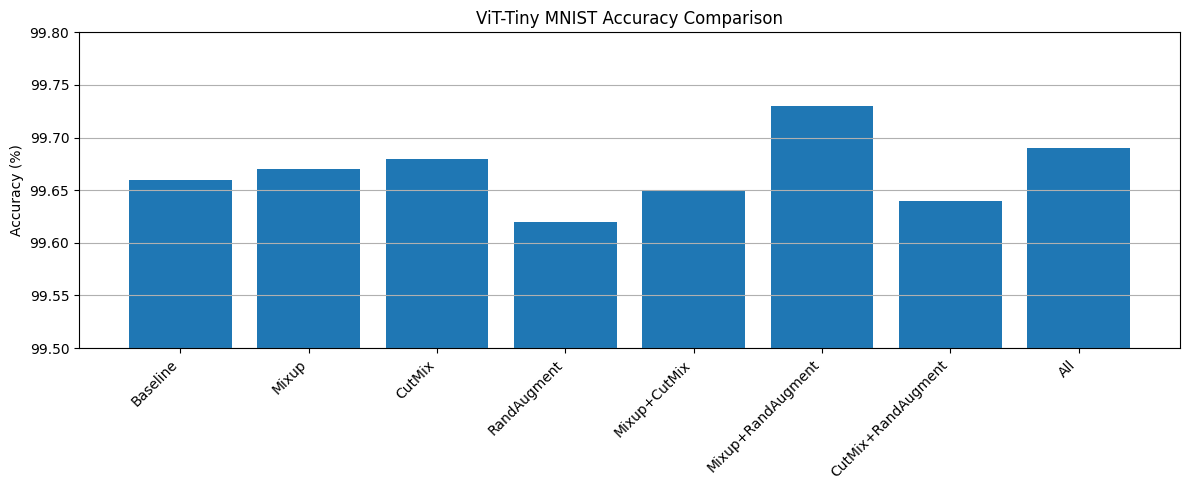

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))


plt.bar(
    mnist_results["Experiment"],
    mnist_results["Accuracy (%)"]
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "ViT-Tiny MNIST Accuracy Comparison"
)


# IMPORTANT: zoom y-axis
plt.ylim(
    99.5,
    99.8
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.savefig(
    "mnist_accuracy_comparison_zoomed.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

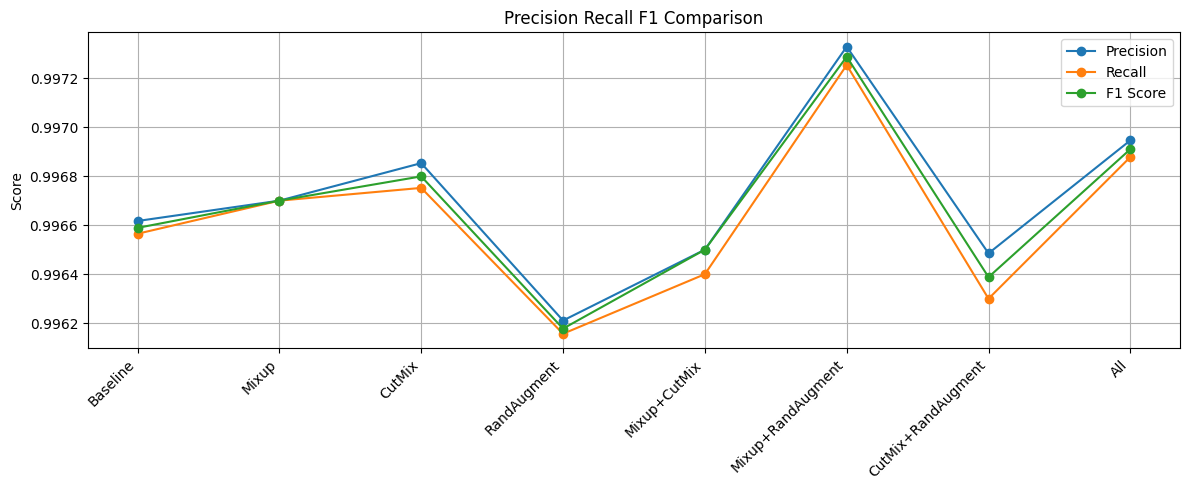

In [ ]:
plt.figure(figsize=(12,5))


x = range(
    len(mnist_results)
)


plt.plot(
    x,
    mnist_results["Precision"],
    marker="o",
    label="Precision"
)


plt.plot(
    x,
    mnist_results["Recall"],
    marker="o",
    label="Recall"
)


plt.plot(
    x,
    mnist_results["F1 Score"],
    marker="o",
    label="F1 Score"
)



plt.xticks(
    x,
    mnist_results["Experiment"],
    rotation=45,
    ha="right"
)


plt.ylabel(
    "Score"
)


plt.title(
    "Precision Recall F1 Comparison"
)


plt.legend()

plt.grid()


plt.tight_layout()


plt.savefig(
    "mnist_precision_recall_f1.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

In [ ]:
best_model = mnist_results.loc[
    mnist_results["Accuracy (%)"].idxmax()
]


best_model

,5
Experiment,Mixup+RandAugment
Accuracy (%),99.73
Precision,0.997328
Recall,0.997253
F1 Score,0.997287


In [ ]:
train_history=[]
val_loss_history=[]
val_acc_history=[]

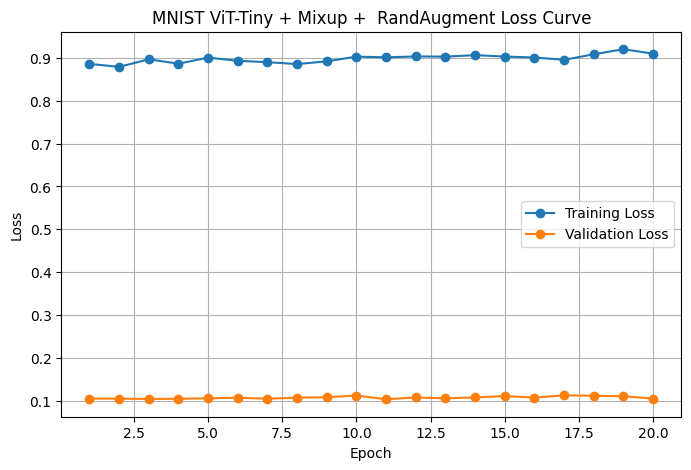

In [ ]:
import matplotlib.pyplot as plt


epochs = list(range(1,21))


train_loss_history = [

0.8856,
0.8786,
0.8962,
0.8860,
0.9001,
0.8928,
0.8895,
0.8851,
0.8915,
0.9025,
0.9008,
0.9029,
0.9024,
0.9059,
0.9026,
0.9004,
0.8950,
0.9079,
0.9197,
0.9094

]


val_loss_history = [

0.1058,
0.1056,
0.1049,
0.1054,
0.1065,
0.1077,
0.1055,
0.1079,
0.1090,
0.1129,
0.1043,
0.1084,
0.1064,
0.1085,
0.1116,
0.1082,
0.1133,
0.1124,
0.1111,
0.1059

]


plt.figure(figsize=(8,5))


plt.plot(
    epochs,
    train_loss_history,
    marker="o",
    label="Training Loss"
)


plt.plot(
    epochs,
    val_loss_history,
    marker="o",
    label="Validation Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.title(
    "MNIST ViT-Tiny + Mixup +  RandAugment Loss Curve"
)


plt.legend()


plt.grid()


plt.savefig(
    "mnist_all_loss_curve.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

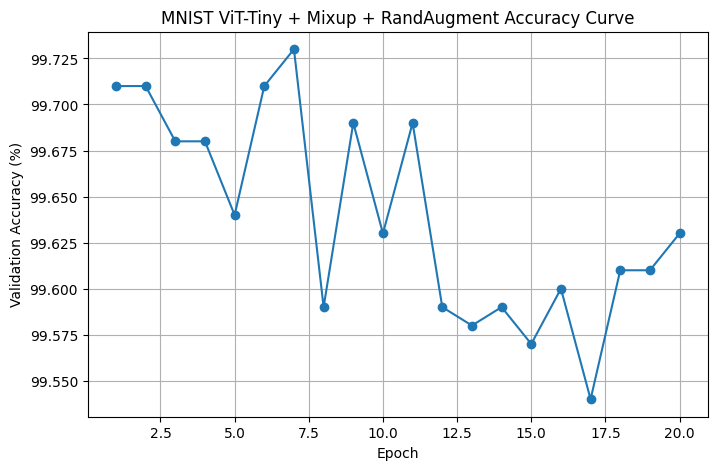

In [ ]:
val_acc_history = [

99.71,
99.71,
99.68,
99.68,
99.64,
99.71,
99.73,
99.59,
99.69,
99.63,
99.69,
99.59,
99.58,
99.59,
99.57,
99.60,
99.54,
99.61,
99.61,
99.63

]


plt.figure(figsize=(8,5))


plt.plot(
    epochs,
    val_acc_history,
    marker="o"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Validation Accuracy (%)"
)


plt.title(
    "MNIST ViT-Tiny + Mixup + RandAugment Accuracy Curve"
)


plt.grid()


plt.savefig(
    "mnist_all_accuracy_curve.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

In [ ]:
import torch
import timm


device="cuda" if torch.cuda.is_available() else "cpu"


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
)


model_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_randaugment_best (1).pth"


model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)


model=model.to(device)

model.eval()


print("Best MNIST model loaded")

Best MNIST model loaded


In [ ]:
from tqdm import tqdm


all_preds=[]
all_labels=[]


with torch.no_grad():

    for images,labels in tqdm(test_loader):

        images=images.to(device)


        outputs=model(images)


        preds=torch.argmax(
            outputs,
            dim=1
        )


        all_preds.extend(
            preds.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )

100%|██████████| 157/157 [00:19<00:00,  8.12it/s]


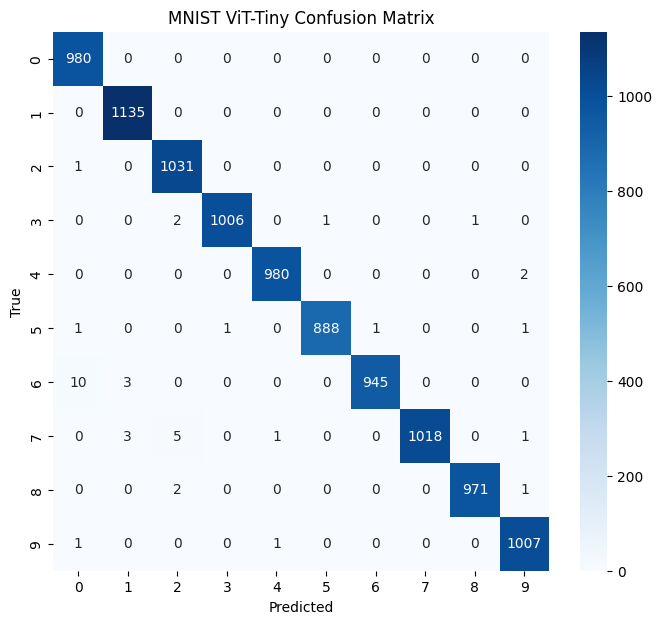

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt



cm = confusion_matrix(
    all_labels,
    all_preds
)



plt.figure(figsize=(8,7))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "True"
)


plt.title(
    "MNIST ViT-Tiny Confusion Matrix"
)


plt.savefig(
    "mnist_confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

In [ ]:
import numpy as np


class_accuracy = (
    cm.diagonal()
    /
    cm.sum(axis=1)
)*100



for i,acc in enumerate(class_accuracy):

    print(
        f"Class {i}: {acc:.2f}%"
    )

Class 0: 100.00%
Class 1: 100.00%
Class 2: 99.90%
Class 3: 99.60%
Class 4: 99.80%
Class 5: 99.55%
Class 6: 98.64%
Class 7: 99.03%
Class 8: 99.69%
Class 9: 99.80%


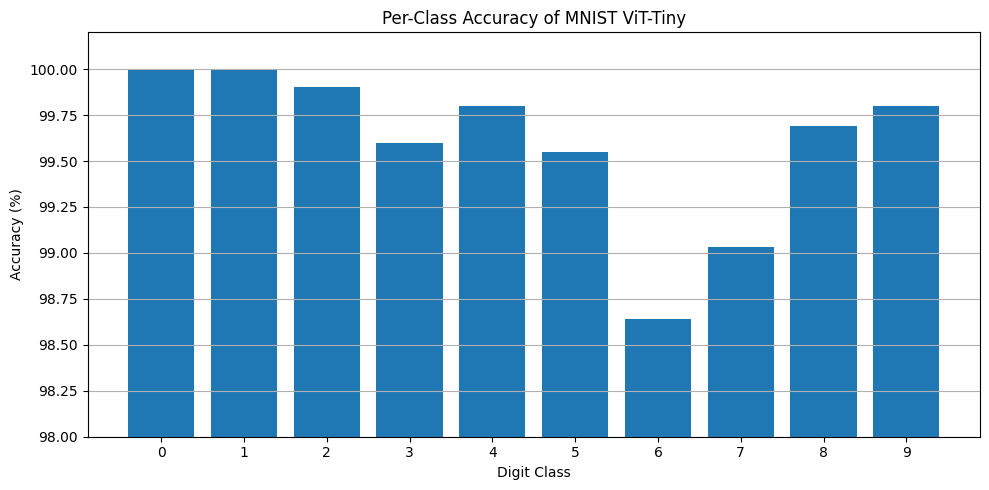

In [ ]:
import matplotlib.pyplot as plt


class_names = [
    "0","1","2","3","4",
    "5","6","7","8","9"
]


class_accuracy = [

100.00,
100.00,
99.90,
99.60,
99.80,
99.55,
98.64,
99.03,
99.69,
99.80

]


plt.figure(figsize=(10,5))


plt.bar(
    class_names,
    class_accuracy
)


plt.xlabel(
    "Digit Class"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "Per-Class Accuracy of MNIST ViT-Tiny"
)


# Zoom the y-axis
plt.ylim(
    98,
    100.2
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.savefig(
    "mnist_per_class_accuracy_zoomed.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

**RA**

In [ ]:
import torch
import timm
import torch.nn as nn


device = "cuda" if torch.cuda.is_available() else "cpu"


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
)


best_model_path = "/content/drive/MyDrive/mnist_vit_tiny_mixup_randaugment_best (1).pth"


state_dict = torch.load(
    best_model_path,
    map_location=device
)


model.load_state_dict(
    state_dict
)


model = model.to(device)

model.eval()


print("Best MNIST ViT-Tiny model loaded")

Best MNIST ViT-Tiny model loaded


In [ ]:
from torchvision import transforms


blur_transform = transforms.Compose([

    transforms.GaussianBlur(
        kernel_size=5
    )

])


brightness_transform = transforms.Compose([

    transforms.ColorJitter(
        brightness=0.5
    )

])


contrast_transform = transforms.Compose([

    transforms.ColorJitter(
        contrast=0.5
    )

])

In [ ]:
def add_noise(image):

    noise = torch.randn_like(image) * 0.1

    noisy = image + noise


    noisy = torch.clamp(
        noisy,
        0,
        1
    )


    return noisy

In [ ]:
from tqdm import tqdm


def evaluate_robustness(
    model,
    dataset,
    transform=None,
    noise=False
):


    model.eval()


    correct = 0
    total = 0



    with torch.no_grad():


        for img,label in tqdm(dataset):


            if transform:

                img = transform(img)



            if noise:

                img = add_noise(img)



            img = img.unsqueeze(0).to(device)


            label = torch.tensor(
                label
            ).to(device)



            output = model(img)


            pred = torch.argmax(
                output,
                dim=1
            )



            correct += (
                pred == label
            ).sum().item()



            total += 1



    return (
        100 * correct / total
    )

In [ ]:
clean_acc = evaluate_robustness(
    model,
    test_dataset
)


noise_acc = evaluate_robustness(
    model,
    test_dataset,
    noise=True
)


blur_acc = evaluate_robustness(
    model,
    test_dataset,
    transform=blur_transform
)


brightness_acc = evaluate_robustness(
    model,
    test_dataset,
    transform=brightness_transform
)


contrast_acc = evaluate_robustness(
    model,
    test_dataset,
    transform=contrast_transform
)



print("Clean :",clean_acc)
print("Noise :",noise_acc)
print("Blur :",blur_acc)
print("Brightness :",brightness_acc)
print("Contrast :",contrast_acc)

100%|██████████| 10000/10000 [01:18<00:00, 127.75it/s]

Clean : 99.61
Noise : 99.58
Blur : 99.64
Brightness : 99.56
Contrast : 99.58


In [ ]:
import pandas as pd


robustness_df = pd.DataFrame({

"Condition":[
    "Clean",
    "Gaussian Noise",
    "Blur",
    "Brightness",
    "Contrast"
],


"Accuracy":[

    clean_acc,
    noise_acc,
    blur_acc,
    brightness_acc,
    contrast_acc

]

})


robustness_df

,Condition,Accuracy
0,Clean,99.61
1,Gaussian Noise,99.58
2,Blur,99.64
3,Brightness,99.56
4,Contrast,99.58


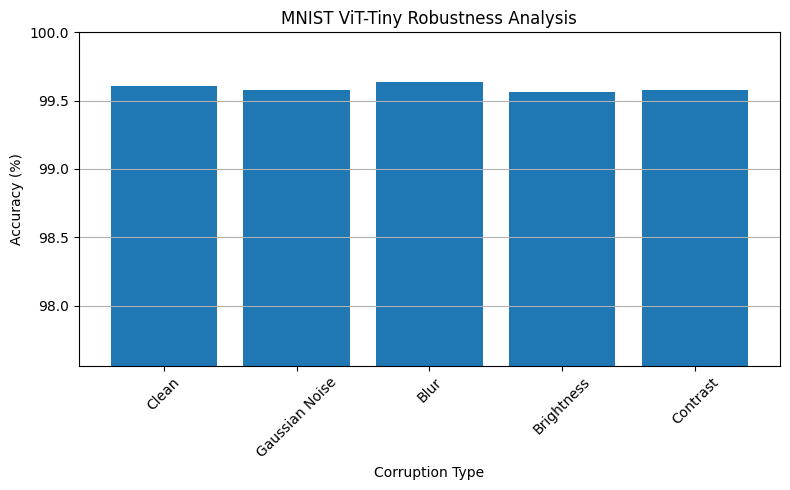

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.bar(
    robustness_df["Condition"],
    robustness_df["Accuracy"]
)


plt.ylabel(
    "Accuracy (%)"
)


plt.xlabel(
    "Corruption Type"
)


plt.title(
    "MNIST ViT-Tiny Robustness Analysis"
)


plt.xticks(
    rotation=45
)


plt.ylim(
    min(robustness_df["Accuracy"])-2,
    100
)


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.savefig(
    "mnist_vit_robustness.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()

# **AV**

In [ ]:
import torch
import timm
import torch.nn as nn


device = "cuda" if torch.cuda.is_available() else "cpu"


model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=False,
    num_classes=10
)


best_model_path="/content/drive/MyDrive/mnist_vit_tiny_mixup_randaugment_best (1).pth"


model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)


model=model.to(device)

model.eval()


print("Best ViT-Tiny loaded")

Best ViT-Tiny loaded


In [ ]:
for block in model.blocks:

    block.attn.fused_attn = False

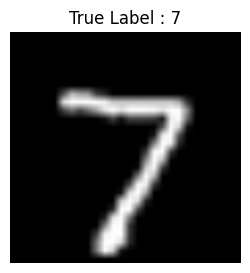

In [ ]:
import matplotlib.pyplot as plt


image,label = test_dataset[0]


plt.figure(figsize=(3,3))


plt.imshow(
    image.permute(1,2,0).cpu()
)


plt.title(
    f"True Label : {label}"
)


plt.axis("off")

plt.show()

In [ ]:
attention_maps = []

In [ ]:
def save_qkv(
    module,
    input,
    output
):

    attention_maps.append(
        output
    )



for block in model.blocks:

    block.attn.qkv.register_forward_hook(
        save_qkv
    )

In [ ]:
img = image.unsqueeze(0).to(device)


with torch.no_grad():

    output = model(img)

In [ ]:
print(
    len(attention_maps)
)

12


In [ ]:
qkv = attention_maps[-1]


print(
    qkv.shape
)

torch.Size([1, 197, 576])


In [ ]:
B,N,C = qkv.shape


num_heads = model.blocks[0].attn.num_heads


head_dim = C // 3 // num_heads



qkv = qkv.reshape(
    B,
    N,
    3,
    num_heads,
    head_dim
)


qkv = qkv.permute(
    2,
    0,
    3,
    1,
    4
)



q = qkv[0]

k = qkv[1]

v = qkv[2]

In [ ]:
attention = (
    q @ k.transpose(-2,-1)
)


attention = attention * (
    head_dim ** -0.5
)


attention = torch.softmax(
    attention,
    dim=-1
)


print(
    attention.shape
)

torch.Size([1, 3, 197, 197])


In [ ]:
attention = attention.mean(
    dim=1
)


attention = attention[0]


# CLS token attention to patches

attention = attention[0,1:]


attention = attention.reshape(
    14,
    14
)


attention = attention.cpu().numpy()

In [ ]:
import cv2
import numpy as np


attention = cv2.resize(
    attention,
    (224,224)
)



attention = (
    attention - attention.min()
) / (
    attention.max()-attention.min()
)

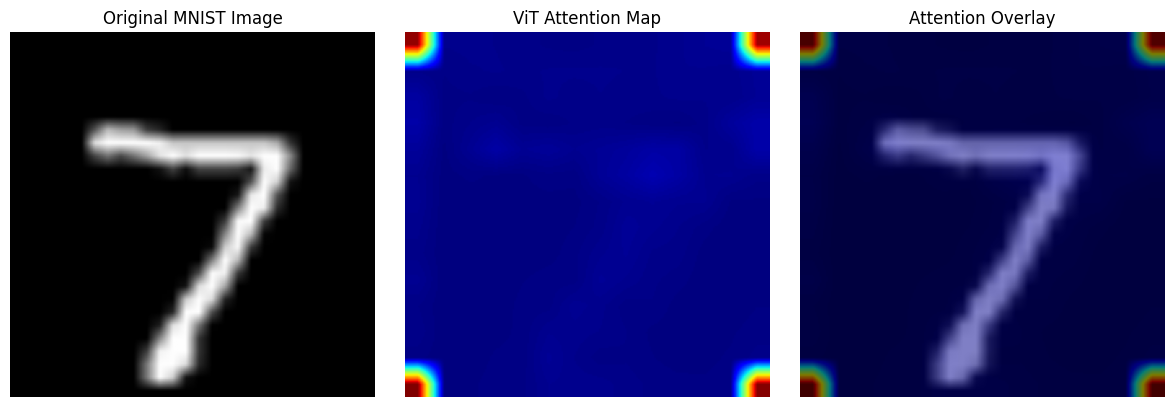

In [ ]:
plt.figure(figsize=(12,4))


# Original image

plt.subplot(1,3,1)

plt.imshow(
    image.permute(1,2,0)
)

plt.title(
    "Original MNIST Image"
)

plt.axis("off")



# Attention map

plt.subplot(1,3,2)

plt.imshow(
    attention,
    cmap="jet"
)

plt.title(
    "ViT Attention Map"
)

plt.axis("off")



# Overlay

plt.subplot(1,3,3)


plt.imshow(
    image.permute(1,2,0)
)


plt.imshow(
    attention,
    cmap="jet",
    alpha=0.5
)


plt.title(
    "Attention Overlay"
)


plt.axis("off")



plt.tight_layout()



plt.savefig(
    "mnist_vit_attention_visualization.png",
    dpi=600,
    bbox_inches="tight"
)


plt.show()